# Style Similarity Search V6 · Qwen3-VL-Embedding

Pure multimodal semantic similarity search using `Qwen3-VL-Embedding-2B`.

> **Design reference:** [Photo Clustering Pipeline — Architecture & Design](docs/Photo%20Clustering%20Pipeline%20-%20Architecture%20%26%20Design.md)  
> **Related notebooks:** [Qwen3-VL Semantic](qwen3_vl_pipeline.ipynb)

| Signal | Model | What it captures |
|---|---|---|
| Semantic | `Qwen3-VL-Embedding-2B` (last hidden state) | Subject, scene content, aesthetic vocabulary, style, mood |

Images are embedded directly — no caption generation step required.
The same model handles **text search queries**, placing text and images in the same embedding space natively.

## Clustering
- **UMAP ×2** — `n_neighbors=min(8, n-1)`, `min_dist=0.0`, cosine metric
  - Pass 1: `n_components=min(15, n-2)` → fed to HDBSCAN
  - Pass 2: `n_components=2` → visualization only
- **HDBSCAN** (`min_cluster_size=max(3, n//15)`, `min_samples=1`, `cluster_selection_method='leaf'`)

## Hardware
Apple M4 Pro · 24 GB Unified Memory

In [7]:
import os, gc, json, warnings, hashlib, colorsys, base64, io
from pathlib import Path
from collections import defaultdict

import torch
import duckdb
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModel
import umap
from sklearn.cluster import HDBSCAN

# --- Config ---
LIMIT         = 'All'
DATA_DIR      = Path('./data/raw')
DB_PATH       = Path('./outputs/photos.duckdb')
RESULTS_PATH  = Path('./outputs/results_v6.json')
MODELS_DIR    = Path('./models')

QWEN_EMB_MODEL = str(MODELS_DIR / 'Qwen3-VL-Embedding-2B')

os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'[✓] Device: {DEVICE}')
print(f'[✓] Qwen embedding model: {QWEN_EMB_MODEL}')

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

[✓] Device: mps
[✓] Qwen embedding model: models/Qwen3-VL-Embedding-2B


In [8]:
def get_file_hash(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        h.update(f.read(65536))
    return h.hexdigest()[:16]

def safe_to_rgb(path):
    img = Image.open(path)
    if img.mode in ('RGBA', 'LA', 'PA'):
        bg = Image.new('RGB', img.size, (255, 255, 255))
        if img.mode == 'PA':
            img = img.convert('RGBA')
        bg.paste(img, mask=img.split()[-1])
        return bg
    return img.convert('RGB')

def discover_images(directory):
    valid_exts = {'.jpg', '.jpeg', '.png', '.tiff', '.webp'}
    return sorted(f for f in directory.rglob('*') if f.suffix.lower() in valid_exts and f.is_file())

def _color_hex(cid):
    if cid == -1:
        return '#888888'
    n_real = len([l for l in labels if l != -1])
    h = (cid / max(n_real, 1)) % 1.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.72, 0.92)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

images_paths = discover_images(DATA_DIR)
if isinstance(LIMIT, int):
    images_paths = images_paths[:LIMIT]
print(f'[✓] {len(images_paths)} images found.')

[✓] 100 images found.


In [9]:
valid_paths = list(images_paths)
print(f'[✓] {len(valid_paths)} images ready for embedding.')

[✓] 100 images ready for embedding.


In [10]:
EMBED_PROMPT = 'Describe the photographic style, mood, lighting, and composition of this image.'

import hashlib as _hl
PROMPT_HASH = _hl.sha256(EMBED_PROMPT.encode()).hexdigest()[:16]

print(f'[i] Stage 2: Qwen3-VL-Embedding-2B image embeddings...')
print(f'[i] Prompt: {EMBED_PROMPT!r}  (hash: {PROMPT_HASH})')

con = duckdb.connect(str(DB_PATH))
con.execute('''
    CREATE TABLE IF NOT EXISTS v6_qwen (
        photo_id    VARCHAR PRIMARY KEY,
        image_path  VARCHAR NOT NULL,
        qwen_emb    FLOAT[] NOT NULL,
        prompt_hash VARCHAR NOT NULL,
        created_at  TIMESTAMP DEFAULT now()
    )
''')

# Add prompt_hash column to existing tables that predate this schema
existing_cols = {r[0] for r in con.execute("DESCRIBE v6_qwen").fetchall()}
if 'prompt_hash' not in existing_cols:
    con.execute("ALTER TABLE v6_qwen ADD COLUMN prompt_hash VARCHAR DEFAULT ''")

# Invalidate any rows cached under a different prompt
stale = con.execute("SELECT COUNT(*) FROM v6_qwen WHERE prompt_hash != ?", [PROMPT_HASH]).fetchone()[0]
if stale:
    con.execute("DELETE FROM v6_qwen WHERE prompt_hash != ?", [PROMPT_HASH])
    print(f'[i] Invalidated {stale} stale embeddings (prompt changed).')

proc        = AutoProcessor.from_pretrained(QWEN_EMB_MODEL)
embed_model = AutoModel.from_pretrained(
    QWEN_EMB_MODEL, dtype=torch.float16, attn_implementation='sdpa', device_map='mps'
)
embed_model.eval()

VL_MAX_SIDE = 1024
def resize_for_vl(img):
    w, h = img.size
    if max(w, h) > VL_MAX_SIDE:
        scale = VL_MAX_SIDE / max(w, h)
        return img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    return img

qwen_embs = []
for path in tqdm(valid_paths, desc='Qwen3-VL-Embedding'):
    pid = get_file_hash(path)
    row = con.execute('SELECT qwen_emb FROM v6_qwen WHERE photo_id = ?', [pid]).fetchone()
    if row:
        qwen_embs.append(np.array(row[0]))
        continue
    try:
        img      = resize_for_vl(safe_to_rgb(path))
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': img},
            {'type': 'text',  'text': EMBED_PROMPT},
        ]}]
        text   = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = proc(text=[text], images=[img], return_tensors='pt', padding=True).to(DEVICE)
        with torch.inference_mode():
            out = embed_model(**inputs)
        emb = out.last_hidden_state[:, -1, :].detach().cpu().float().numpy().flatten()
        emb /= (np.linalg.norm(emb) + 1e-8)
        con.execute(
            'INSERT INTO v6_qwen (photo_id, image_path, qwen_emb, prompt_hash) VALUES (?, ?, ?, ?)',
            [pid, str(path.resolve()), emb.tolist(), PROMPT_HASH]
        )
        qwen_embs.append(emb)
    except Exception as e:
        print(f'[!] {path.name}: {e}')

con.close()
del embed_model, proc
torch.mps.empty_cache()
gc.collect()
qwen_embs = np.array(qwen_embs)
print(f'[✓] {len(qwen_embs)} Qwen3-VL embeddings ready.')

[i] Stage 2: Qwen3-VL-Embedding-2B image embeddings...
[i] Prompt: 'Describe the photographic style, mood, lighting, and composition of this image.'  (hash: 80b3b5bd382c8eca)


Qwen3-VL-Embedding: 100%|██████████| 100/100 [00:00<00:00, 2028.98it/s]


[✓] 100 Qwen3-VL embeddings ready.


## Clustering Configuration

Adjust the parameters below, then run the **Clustering Config** cell followed by the **Clustering** cell. No re-embedding required.

### UMAP
| Parameter | Default | What it does |
|---|---|---|
| `N_NEIGHBORS` | `15` | How many neighbors each point considers when building the layout. **Higher** → more global structure, smoother spread. **Lower** → tighter local groupings, more fragmentation. Good range for <200 images: **10–20**. |
| `N_COMPONENTS_CLUSTER` | `15` | Dimensions passed to HDBSCAN. Higher preserves more structure; rarely worth exceeding 20. |

### HDBSCAN
| Parameter | Default | What it does |
|---|---|---|
| `MIN_CLUSTER_SIZE` | `4` | Minimum images needed to form a cluster. **Lower** → more, smaller clusters and fewer noise points. **Higher** → fewer, larger clusters with more noise. Start at **3–5** for datasets under 200 images. |
| `MIN_SAMPLES` | `1` | How conservative HDBSCAN is about declaring core points. `1` = most permissive (every point can anchor a cluster, minimal noise). `2+` = stricter, more noise. |
| `CLUSTER_SELECTION_METHOD` | `'eom'` | Which clusters to extract from the hierarchy. **`'eom'`** (excess of mass) picks **broader, more stable** clusters. **`'leaf'`** picks the most granular clusters — ⚠️ do not combine `'leaf'` with a non-zero `CLUSTER_SELECTION_EPSILON` (sklearn 1.8 bug). |
| `CLUSTER_SELECTION_EPSILON` | `0.0` | Distance threshold below which nearby micro-clusters are merged. Only works correctly with `'eom'`. Raise (e.g. `0.1–0.3`) to consolidate over-fragmented results. |

### Tuning recipes
- **Too many tiny clusters:** raise `CLUSTER_SELECTION_EPSILON` (try `0.15` → `0.25` → `0.4`).
- **Everything merged into one giant cluster:** lower `CLUSTER_SELECTION_EPSILON` toward `0.0`.
- **Too many noise points:** set `MIN_SAMPLES=1`, or lower `MIN_CLUSTER_SIZE`.
- **Clusters feel too loose / mixed:** raise `MIN_SAMPLES` to `2–3`.
- **Want finer splits without the epsilon bug:** use `'leaf'` only with `CLUSTER_SELECTION_EPSILON=0.0`.

In [ ]:
# ── UMAP ──────────────────────────────────────────────────────────────────────
N_NEIGHBORS               = 8      # global structure ↑ as value increases
N_COMPONENTS_CLUSTER      = 8      # dims fed to HDBSCAN

# ── HDBSCAN ───────────────────────────────────────────────────────────────────
MIN_CLUSTER_SIZE          = 6       # higher = fewer, larger clusters
MIN_SAMPLES               = 1       # 1 = most permissive → minimal noise
CLUSTER_SELECTION_METHOD  = 'leaf'  # granular splits; keep epsilon=0.0 to avoid sklearn 1.8 bug
CLUSTER_SELECTION_EPSILON = 0.0    # must stay 0.0 with 'leaf' (sklearn 1.8 Cython bug with non-zero)

print(f'[✓] N_NEIGHBORS={N_NEIGHBORS}  N_COMPONENTS_CLUSTER={N_COMPONENTS_CLUSTER}')
print(f'[✓] MIN_CLUSTER_SIZE={MIN_CLUSTER_SIZE}  MIN_SAMPLES={MIN_SAMPLES}')
print(f'[✓] METHOD={CLUSTER_SELECTION_METHOD!r}  EPSILON={CLUSTER_SELECTION_EPSILON}')


In [12]:
print('[i] Clustering: UMAP → HDBSCAN...')
# Tuning guide: docs/Photo Clustering Pipeline - Architecture & Design.md#tuning

con       = duckdb.connect(str(DB_PATH))
qwen_rows = con.execute('SELECT photo_id, image_path, qwen_emb FROM v6_qwen').fetchall()
con.close()

print(f'[i] v6_qwen: {len(qwen_rows)} rows')

if not qwen_rows:
    raise RuntimeError('v6_qwen is empty — re-run Stage 1.')

qwen_by_id  = {r[0]: (r[1], np.array(r[2])) for r in qwen_rows}
shared_ids  = [get_file_hash(p) for p in images_paths if get_file_hash(p) in qwen_by_id]
valid_paths = [p for p in images_paths if get_file_hash(p) in qwen_by_id]

print(f'[i] Embedded images: {len(shared_ids)}')

qwen_matrix = np.array([qwen_by_id[pid][1] for pid in shared_ids])
print(f'[i] Embedding matrix: {qwen_matrix.shape}')

n           = len(qwen_matrix)
n_neigh     = min(N_NEIGHBORS, n - 1)
n_comp      = min(N_COMPONENTS_CLUSTER, n - 2)
init_method = 'spectral' if n > 40 else 'random'

reducer = umap.UMAP(
    n_components=n_comp,
    n_neighbors=n_neigh,
    min_dist=0.0,
    metric='cosine',
    init=init_method,
    random_state=42,
)
reduced = reducer.fit_transform(qwen_matrix)

vis_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=n_neigh,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)
vis_2d = vis_reducer.fit_transform(reduced)

clusterer = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    cluster_selection_epsilon=CLUSTER_SELECTION_EPSILON,
    metric='euclidean',
)
labels = clusterer.fit_predict(reduced)

clusters = defaultdict(list)
for path, label in zip(valid_paths, labels):
    clusters[int(label)].append(path)

n_real  = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'[✓] {n_real} clusters, {n_noise} noise points.')

[i] Clustering: UMAP → HDBSCAN...
[i] v6_qwen: 101 rows
[i] Embedded images: 100
[i] Embedding matrix: (100, 2048)
[✓] 6 clusters, 1 noise points.


[i] Generating visualizations...


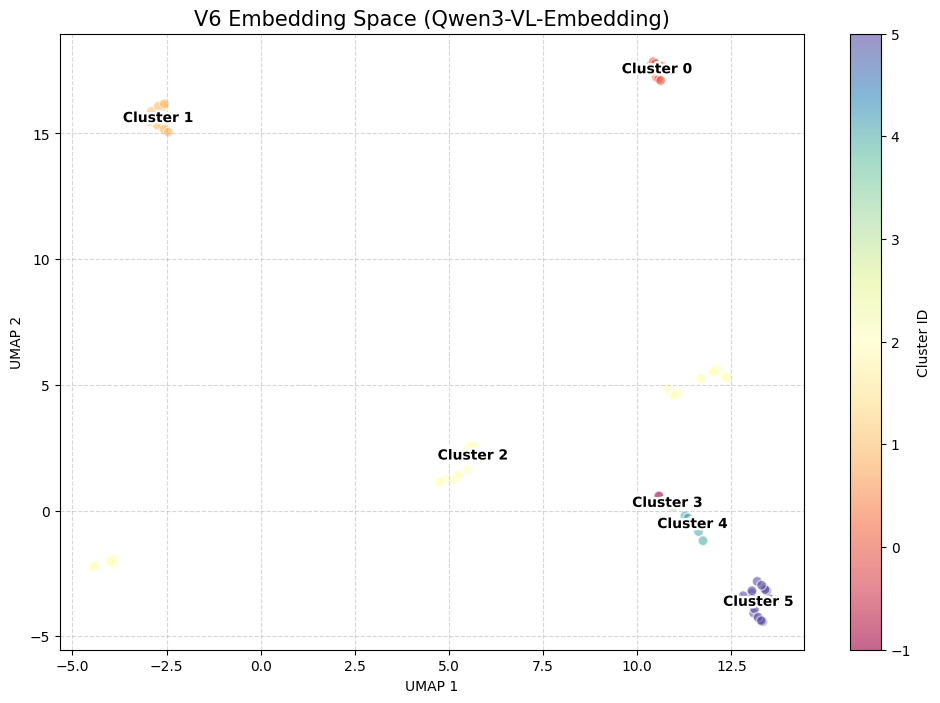


  NOISE (OUTLIERS) | 1 Images


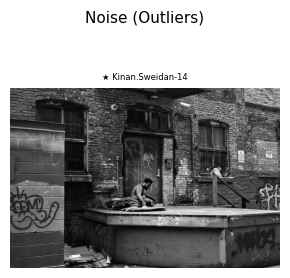


  CLUSTER 0 | 11 Images


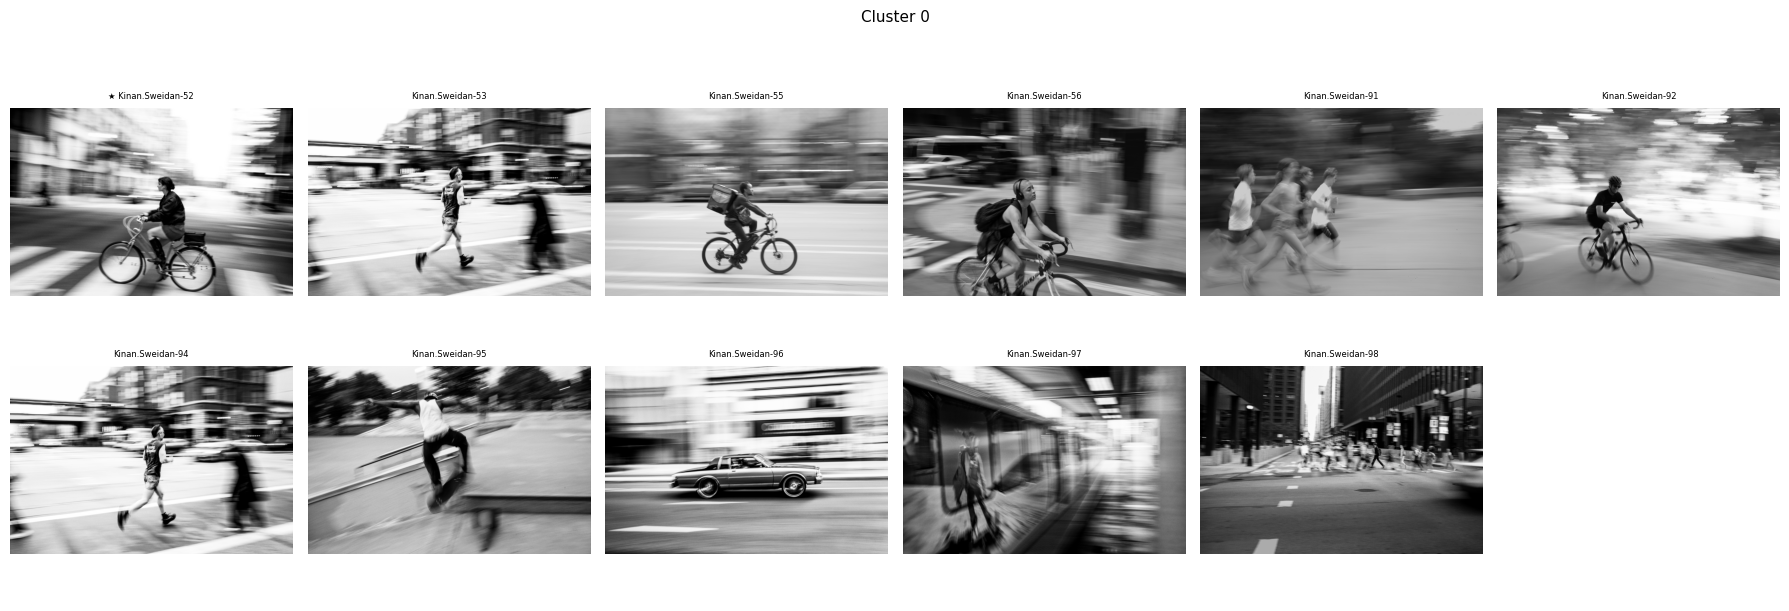


  CLUSTER 1 | 14 Images


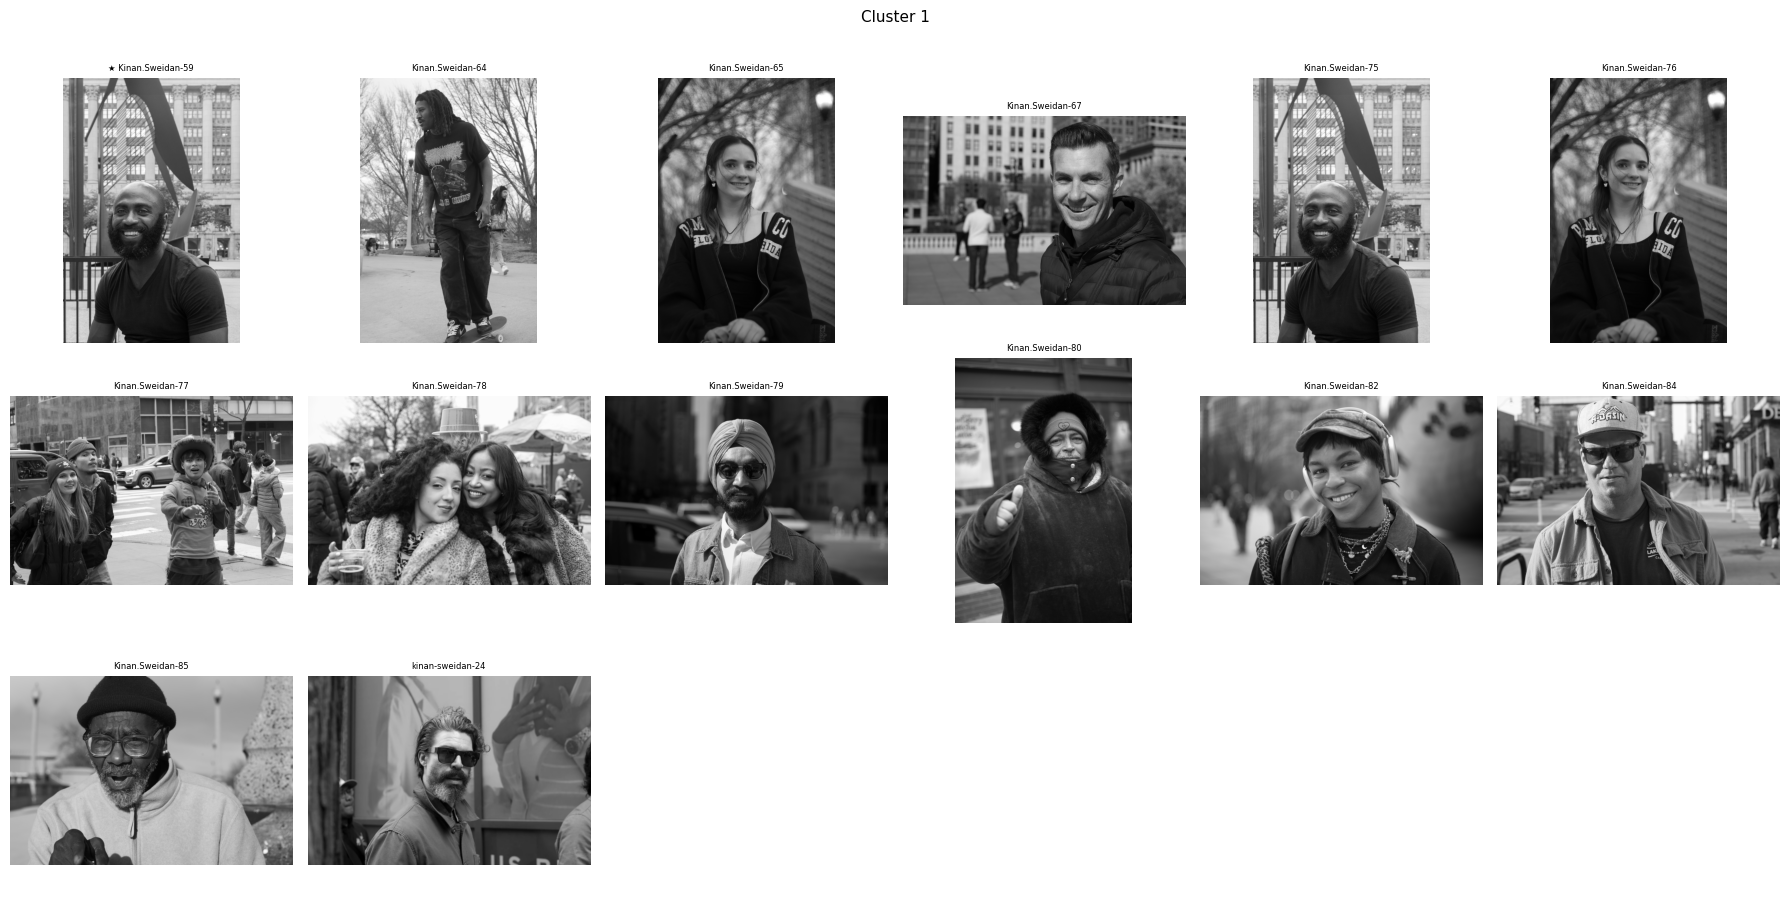


  CLUSTER 2 | 45 Images


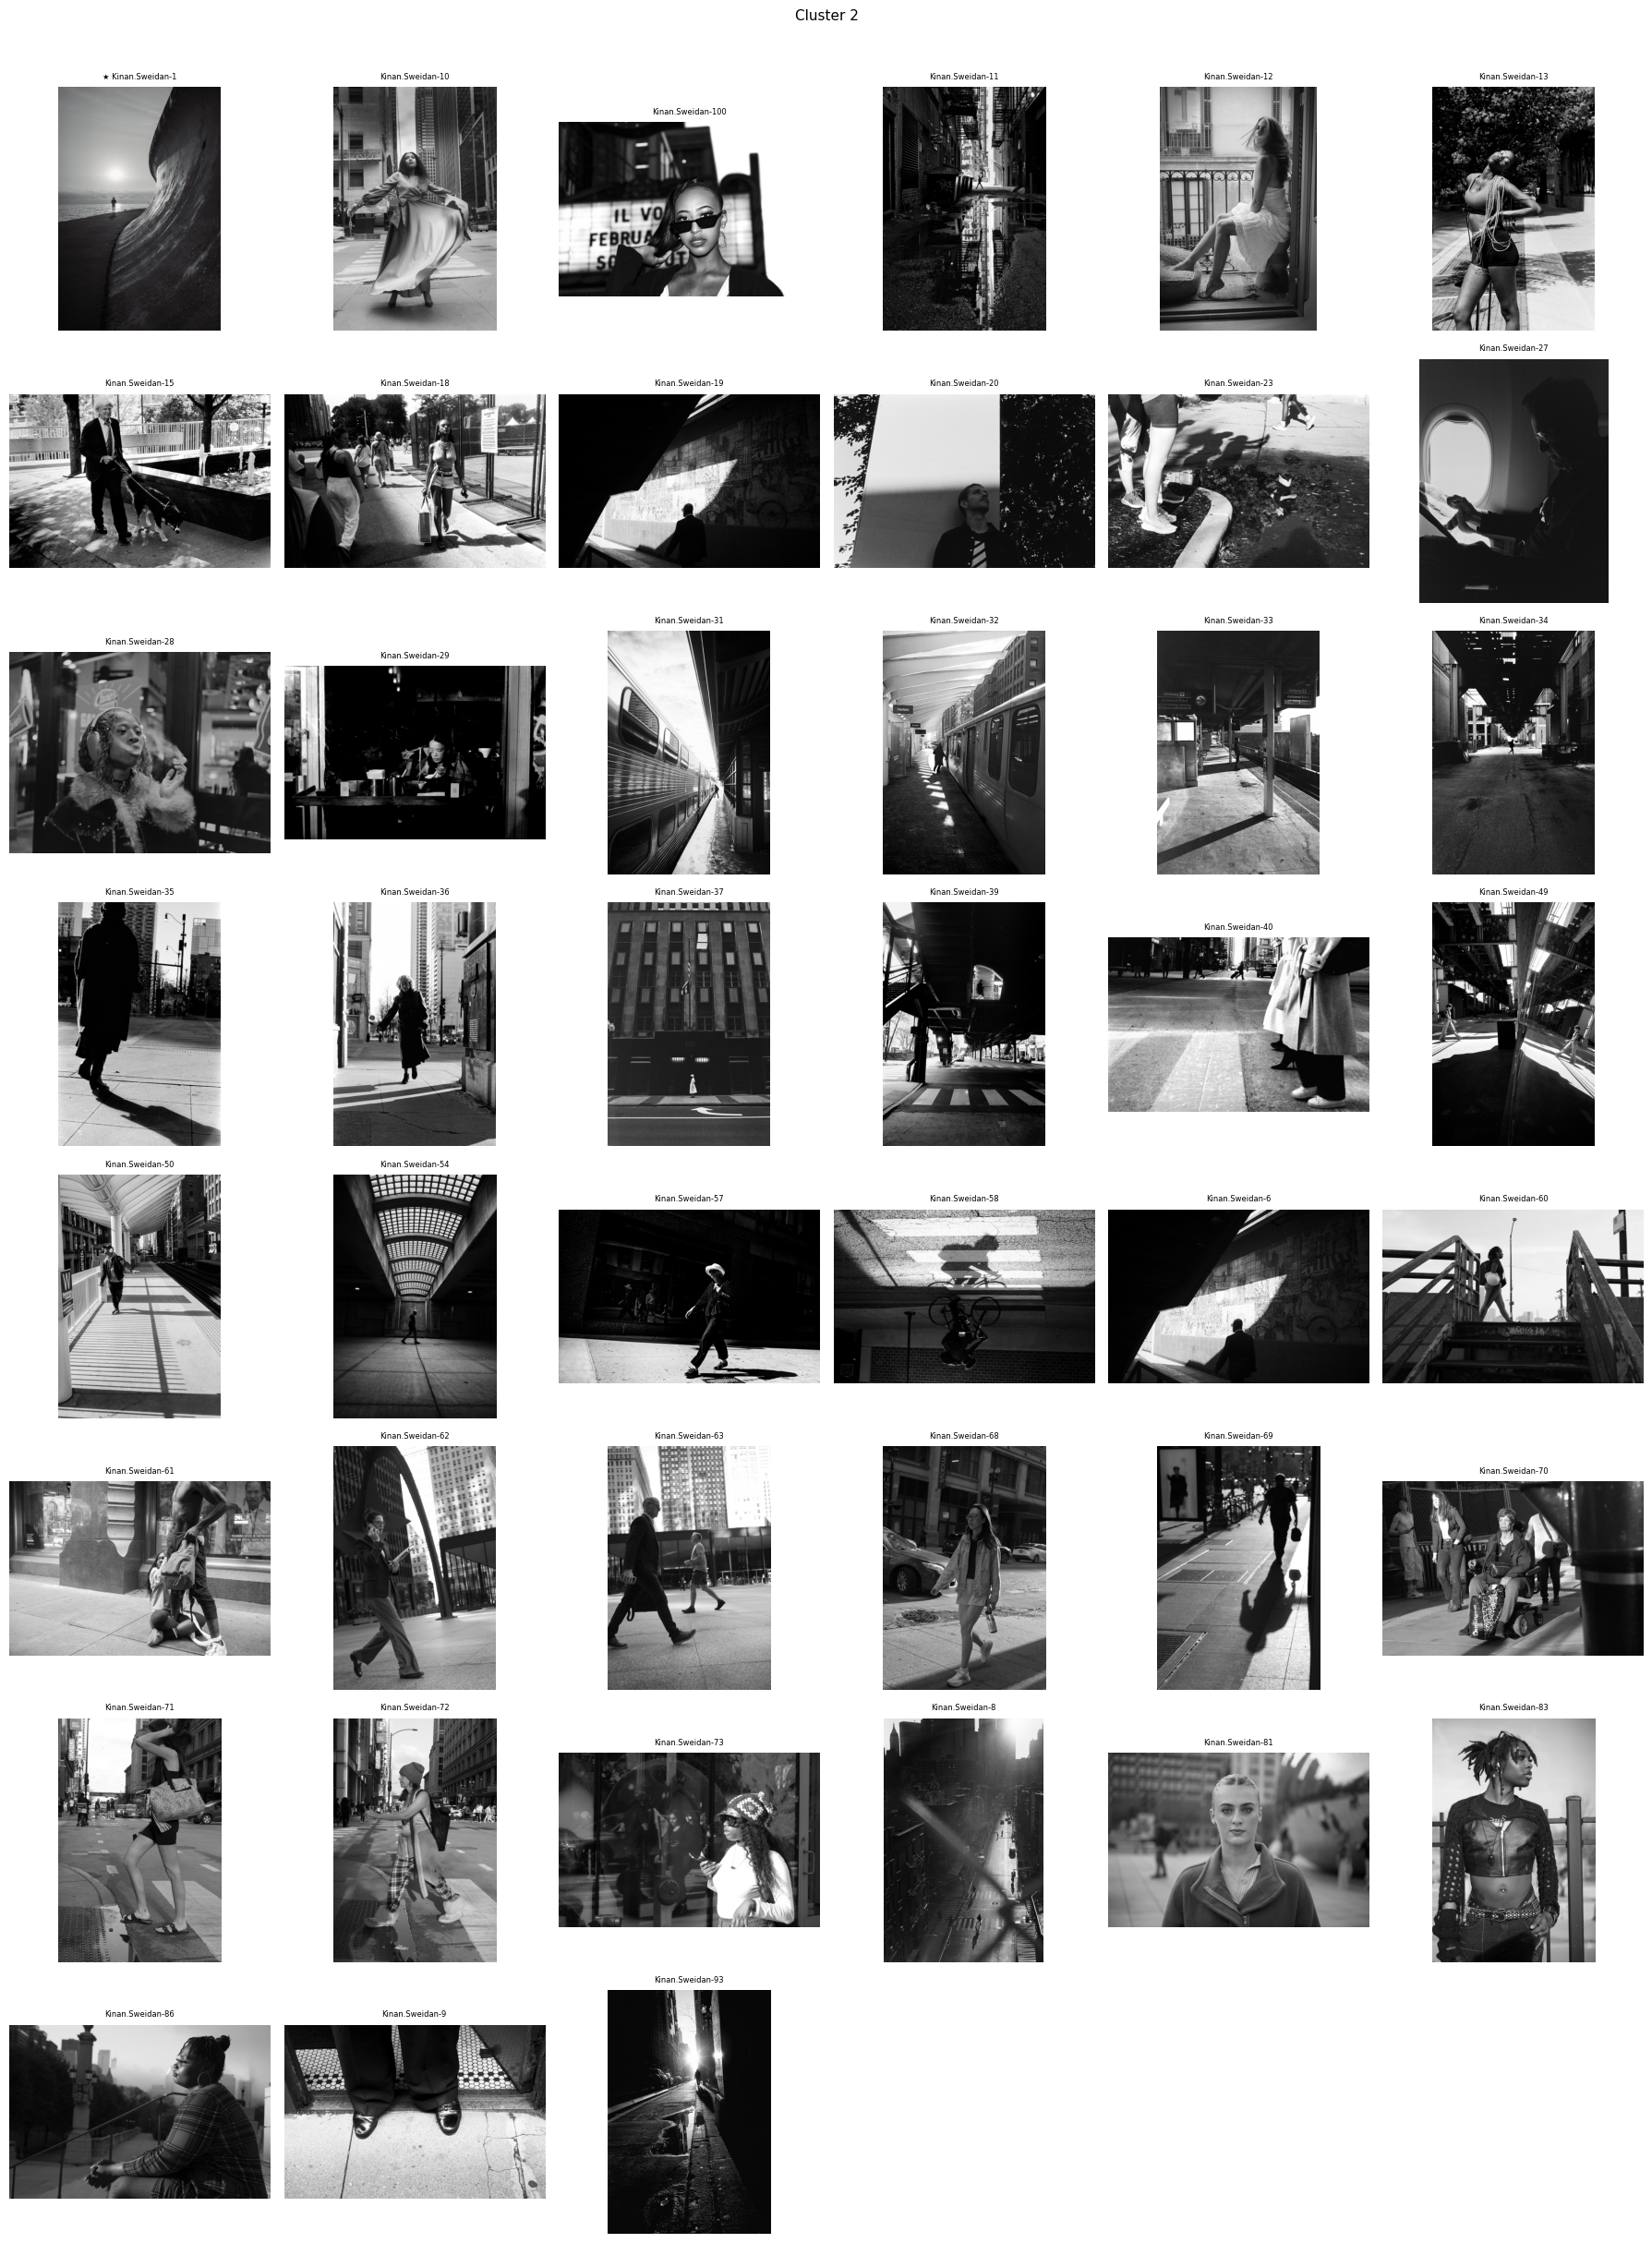


  CLUSTER 3 | 5 Images


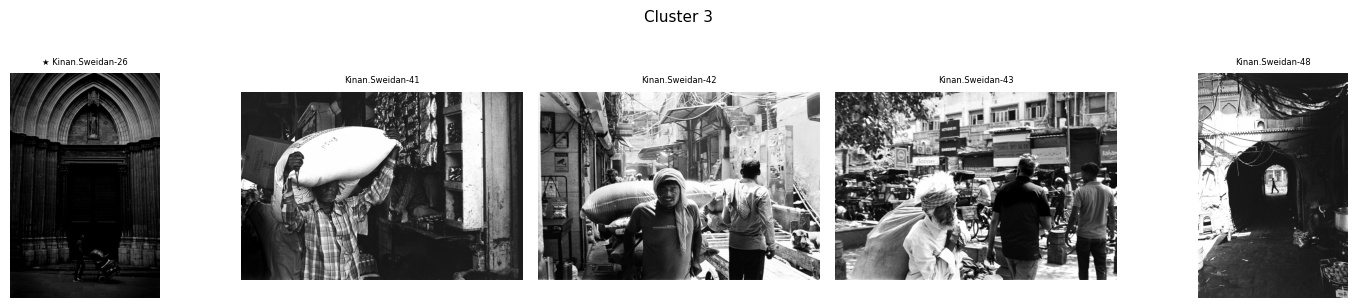


  CLUSTER 4 | 7 Images


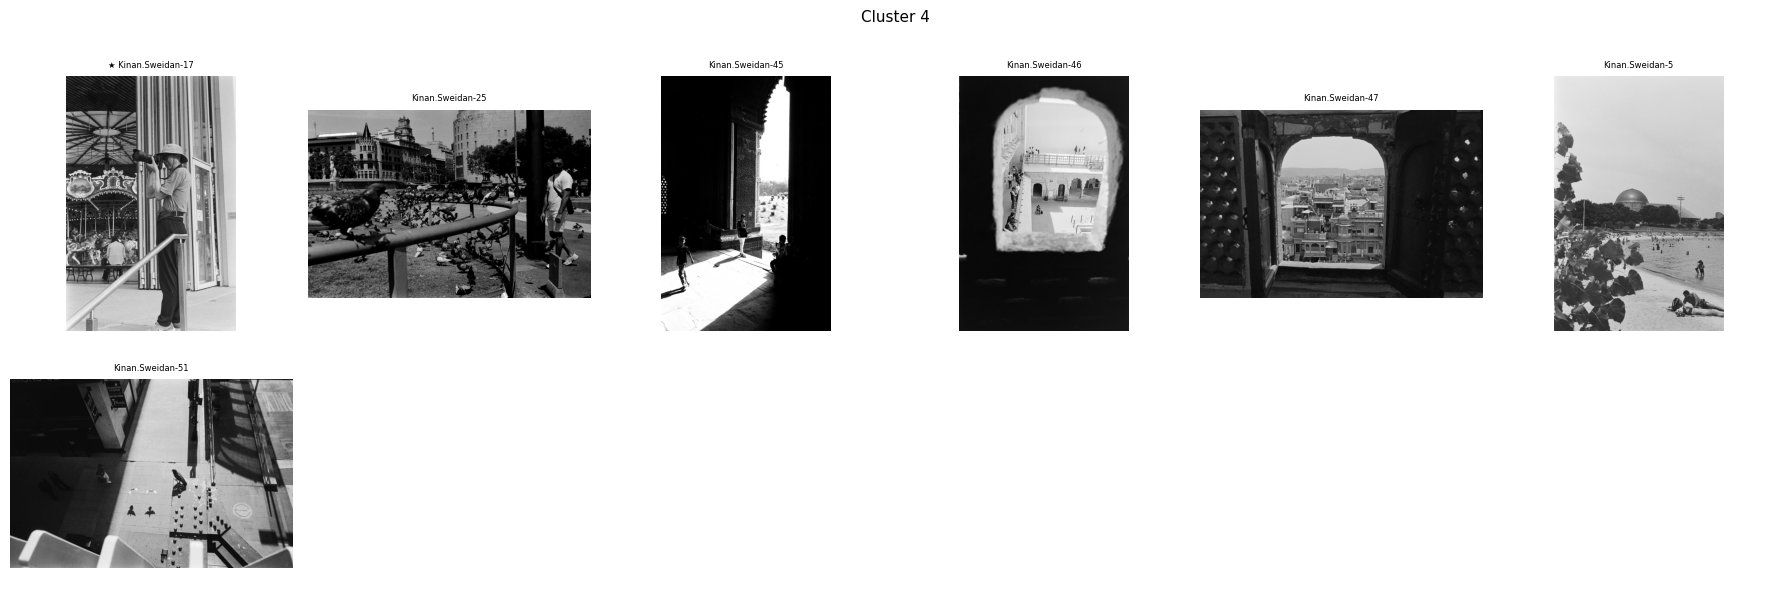


  CLUSTER 5 | 17 Images


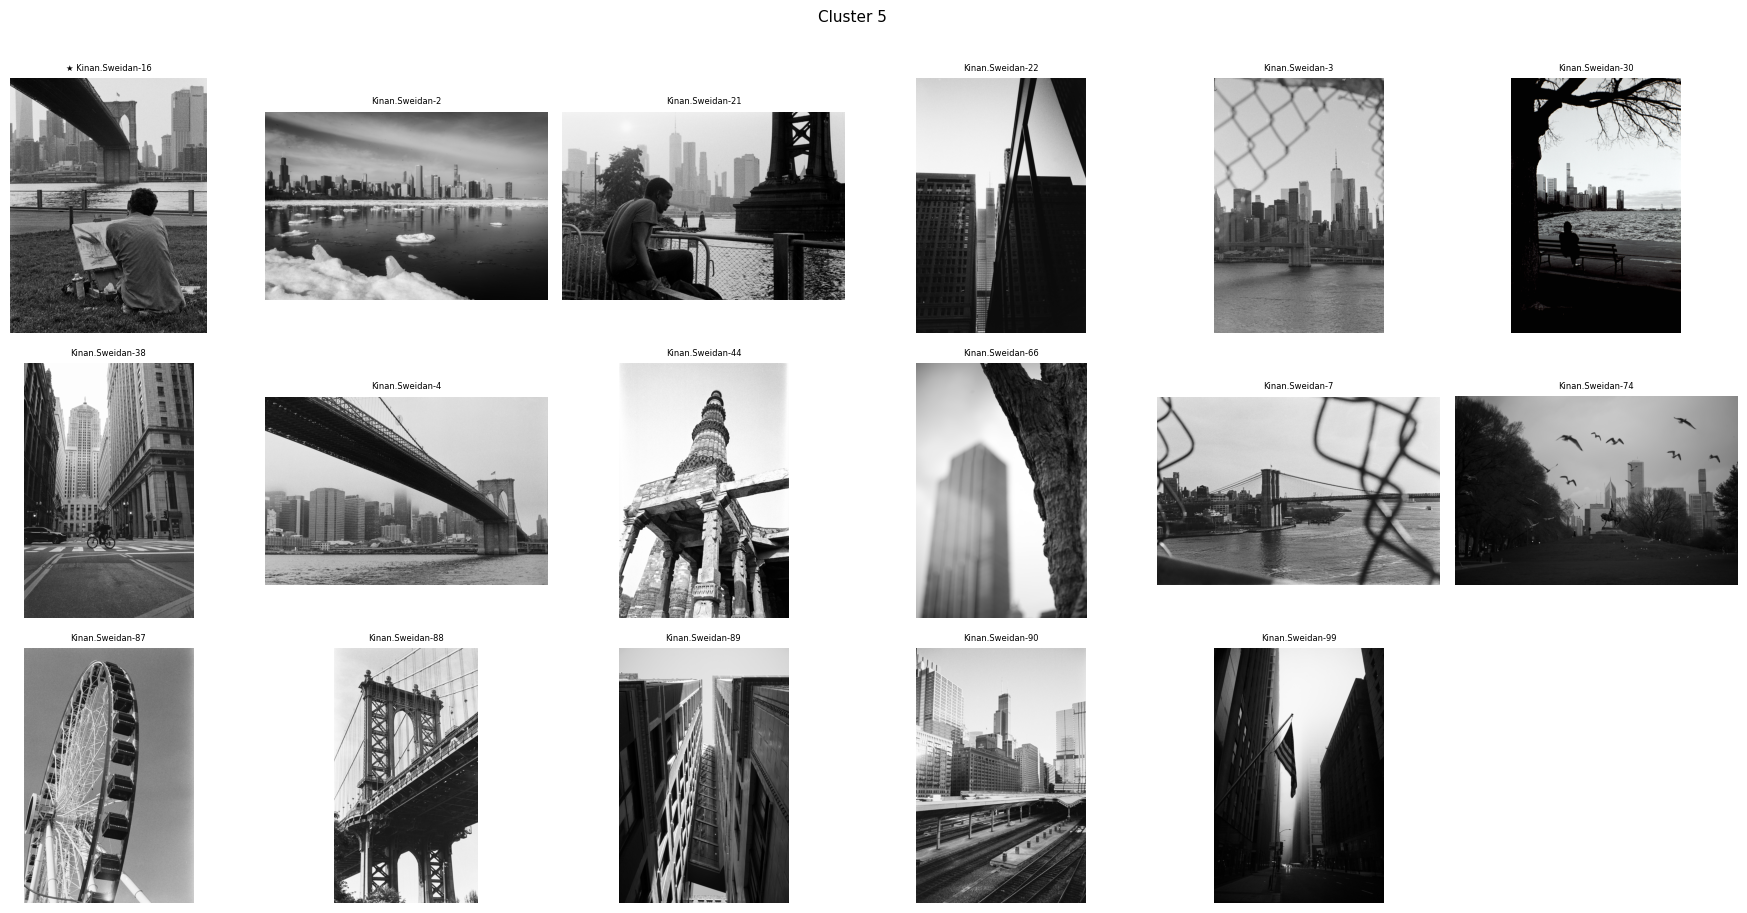

In [13]:
import matplotlib.patheffects as pe

print('[i] Generating visualizations...')

if 'vis_2d' in locals() and len(vis_2d) > 0:
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(vis_2d[:, 0], vis_2d[:, 1], c=labels, cmap='Spectral',
                          s=50, alpha=0.6, edgecolors='w')
    plt.colorbar(scatter, label='Cluster ID')

    # Label each cluster at its centroid — black text with white halo so the
    # dots underneath remain visible (no opaque background box).
    labels_arr = np.array(labels)
    for cid in sorted(set(int(l) for l in labels_arr)):
        if cid == -1:
            continue
        mask = labels_arr == cid
        cx, cy = vis_2d[mask, 0].mean(), vis_2d[mask, 1].mean()
        plt.text(
            cx, cy, f'Cluster {cid}',
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='#000',
            path_effects=[pe.withStroke(linewidth=3.5, foreground='white')],
            zorder=10,
        )

    plt.title('V6 Embedding Space (Qwen3-VL-Embedding)', fontsize=15)
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

cluster_results = [
    {
        'cluster_id':          cid,
        'representative_path': str(clusters[cid][0]),
        'member_count':        len(clusters[cid]),
        'sample_images':       [str(p) for p in clusters[cid]],
    }
    for cid in sorted(clusters.keys())
]

COLS = 6
for res in cluster_results:
    cid  = res['cluster_id']
    name = 'Noise (Outliers)' if cid == -1 else f'Cluster {cid}'
    all_images = res['sample_images']
    print(f"\n{'='*80}\n  {name.upper()} | {res['member_count']} Images\n{'='*80}")

    n_imgs = len(all_images)
    n_cols = min(COLS, n_imgs)
    n_rows = (n_imgs + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axes = np.array(axes).reshape(-1) if n_imgs > 1 else [axes]
    for i, img_path in enumerate(all_images):
        axes[i].imshow(safe_to_rgb(Path(img_path)))
        axes[i].axis('off')
        is_rep = (img_path == res['representative_path'])
        stem   = Path(img_path).stem
        axes[i].set_title(f'★ {stem}' if is_rep else stem, fontsize=6)
    for ax in axes[n_imgs:]:
        ax.axis('off')
    plt.suptitle(name, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

In [14]:
HTML_OUT = Path('./outputs/html/clusters_v6_interactive.html')
HTML_OUT.parent.mkdir(parents=True, exist_ok=True)

THUMB_SIZE = 220
print('[i] Encoding thumbnails...')

def _thumb_b64(path, size=THUMB_SIZE):
    img = Image.open(path).convert('RGB')
    img.thumbnail((size, size))
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=80)
    return 'data:image/jpeg;base64,' + base64.b64encode(buf.getvalue()).decode()

W, H, PAD = 900, 560, 44
x_min, x_max = float(vis_2d[:, 0].min()), float(vis_2d[:, 0].max())
y_min, y_max = float(vis_2d[:, 1].min()), float(vis_2d[:, 1].max())

def _to_px(x, y):
    px = PAD + (x - x_min) / (x_max - x_min + 1e-8) * (W - 2 * PAD)
    py = PAD + (1 - (y - y_min) / (y_max - y_min + 1e-8)) * (H - 2 * PAD)
    return round(px, 1), round(py, 1)

cluster_imgs    = {}
cluster_idx_ctr = {}
point_meta      = []

for (x, y), label, path in zip(vis_2d, labels, valid_paths):
    key = str(int(label))
    t   = _thumb_b64(path)
    cluster_imgs.setdefault(key, []).append(t)
    idx = cluster_idx_ctr.get(key, 0)
    cluster_idx_ctr[key] = idx + 1
    px, py = _to_px(float(x), float(y))
    color  = _color_hex(int(label))
    name   = Path(path).name.replace('"', '').replace("'", '')
    point_meta.append((key, idx, px, py, color, name))

print(f'    {len(point_meta)} photos · {len(cluster_imgs)} clusters')

import json as _json

img_tags = [
    f'<img data-c="{key}" data-i="{idx}" '
    f'style="left:{px}px;top:{py}px;--cc:{color}" '
    f'data-cluster="{key}" title="{name}">'
    for key, idx, px, py, color, name in point_meta
]
legend_items = []
for key in sorted(cluster_imgs.keys(), key=lambda k: int(k)):
    cid   = int(key)
    color = _color_hex(cid)
    lname = 'Noise' if cid == -1 else f'Cluster {cid}'
    count = len(cluster_imgs[key])
    legend_items.append(
        f'<div class="li" data-cluster="{key}" style="border-left-color:{color}">'
        f'<span class="ln">{lname}</span><span class="lc">{count}</span></div>'
    )

cluster_images_json = _json.dumps(cluster_imgs)
photos_html         = '\n'.join(img_tags)
legend_html         = '\n'.join(legend_items)

css = """
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { background: #111; color: #eee; font-family: system-ui, sans-serif; }
  header { text-align: center; padding: 18px 0 6px; font-size: 1.2rem; font-weight: 600; color: #bbb; letter-spacing: .03em; }
  #hint { text-align: center; font-size: .78rem; color: #555; margin-bottom: 10px; }
  #explorer { display: flex; align-items: flex-start; gap: 14px; max-width: 1080px; margin: 0 auto; padding: 0 16px; }
  #left-col { display: flex; flex-direction: column; gap: 16px; flex-shrink: 0; }
  #scatter-wrap { position: relative; width: 900px; height: 560px; background: #1a1a1a; border-radius: 8px; overflow: hidden; cursor: grab; border: 1px solid #2a2a2a; user-select: none; }
  #scatter-inner { position: absolute; inset: 0; transform-origin: 0 0; }
  #scatter-inner img { position: absolute; width: 14px; height: 14px; border-radius: 50%; border: 2px solid var(--cc, #888); background-color: var(--cc, #888); object-fit: cover; transform: translate(-50%, -50%); cursor: pointer; transition: width .18s ease, height .18s ease, border-radius .18s ease, background-color .18s ease; z-index: 1; }
  #scatter-inner img:hover { width: 120px; height: 120px; border-radius: 8px; background-color: transparent; z-index: 100; }
  #legend { min-width: 136px; display: flex; flex-direction: column; gap: 5px; padding-top: 2px; }
  .li { display: flex; justify-content: space-between; align-items: center; padding: 5px 10px; border-left: 4px solid #555; background: #1c1c1c; border-radius: 0 5px 5px 0; cursor: pointer; transition: background .1s; font-size: .8rem; }
  .li:hover { background: #272727; }
  .ln { color: #ccc; } .lc { color: #555; font-size: .72rem; margin-left: 8px; }
  #cluster-panel { display: none; width: 900px; background: #1c1c1c; border-radius: 10px; border: 1px solid #2e2e2e; padding: 18px 20px; }
  #cluster-title { font-size: 1rem; font-weight: 600; margin-bottom: 14px; color: #99ccff; }
  #photo-grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(148px, 1fr)); gap: 8px; }
  #photo-grid img { width: 100%; border-radius: 6px; border: 1px solid #2a2a2a; object-fit: cover; aspect-ratio: 1; cursor: zoom-in; transition: transform .12s, border-color .12s; }
  #photo-grid img:hover { transform: scale(1.05); border-color: #555; }
  #lightbox { display: none; position: fixed; inset: 0; background: rgba(0,0,0,.9); justify-content: center; align-items: center; z-index: 999; }
  #lightbox.open { display: flex; }
  #lightbox img { max-width: 92vw; max-height: 92vh; border-radius: 6px; }
  #lb-close { position: fixed; top: 16px; right: 22px; font-size: 2rem; cursor: pointer; color: #aaa; user-select: none; }
  #lb-close:hover { color: #fff; }
"""

js = """
const clusterImages = """ + cluster_images_json + """;
document.querySelectorAll('#scatter-inner img[data-c]').forEach(img => {
  img.src = clusterImages[img.dataset.c][parseInt(img.dataset.i)];
});
const wrap=document.getElementById('scatter-wrap'),inner=document.getElementById('scatter-inner'),
      panel=document.getElementById('cluster-panel'),title=document.getElementById('cluster-title'),
      grid=document.getElementById('photo-grid'),lb=document.getElementById('lightbox'),
      lbImg=document.getElementById('lb-img');
function showCluster(cid){
  const key=String(cid),imgs=clusterImages[key]||[],
        name=key==='-1'?'Noise / Outliers':'Cluster '+key;
  title.textContent=name+'  —  '+imgs.length+' photo'+(imgs.length!==1?'s':'');
  grid.innerHTML='';
  imgs.forEach(src=>{const img=document.createElement('img');img.src=src;
    img.addEventListener('click',()=>{lbImg.src=src;lb.classList.add('open');});
    grid.appendChild(img);});
  panel.style.display='block';panel.scrollIntoView({behavior:'smooth',block:'nearest'});
}
document.querySelectorAll('#scatter-inner img').forEach(img=>{
  img.addEventListener('click',e=>{e.stopPropagation();showCluster(img.dataset.cluster);});
});
document.querySelectorAll('.li').forEach(item=>{
  item.addEventListener('click',()=>showCluster(item.dataset.cluster));
});
let scale=1,tx=0,ty=0;
wrap.addEventListener('wheel',e=>{e.preventDefault();
  const rect=wrap.getBoundingClientRect(),mx=e.clientX-rect.left,my=e.clientY-rect.top;
  const ns=Math.max(0.35,Math.min(6,scale*(e.deltaY<0?1.12:0.89)));
  tx=mx-(mx-tx)*(ns/scale);ty=my-(my-ty)*(ns/scale);scale=ns;
  inner.style.transform='translate('+tx+'px,'+ty+'px) scale('+scale+')';
},{passive:false});
let dragging=false,ox=0,oy=0;
wrap.addEventListener('mousedown',e=>{dragging=true;ox=e.clientX-tx;oy=e.clientY-ty;wrap.style.cursor='grabbing';});
document.addEventListener('mousemove',e=>{if(!dragging)return;tx=e.clientX-ox;ty=e.clientY-oy;
  inner.style.transform='translate('+tx+'px,'+ty+'px) scale('+scale+')';});
document.addEventListener('mouseup',()=>{dragging=false;wrap.style.cursor='grab';});
document.getElementById('lb-close').addEventListener('click',()=>lb.classList.remove('open'));
lb.addEventListener('click',e=>{if(e.target===lb)lb.classList.remove('open');});
document.addEventListener('keydown',e=>{if(e.key==='Escape')lb.classList.remove('open');});
"""

html = (
    '<!DOCTYPE html>\n<html lang=\"en\">\n<head>\n'
    '<meta charset=\"UTF-8\">\n<title>V6 Photo Cluster Explorer</title>\n'
    '<style>' + css + '</style>\n</head>\n<body>\n'
    '<header>Photo Cluster Explorer &middot; Qwen3-VL-Embedding (V6)</header>\n'
    '<div id=\"hint\">Scroll to zoom &middot; Drag to pan &middot; Hover to preview &middot; Click to see cluster</div>\n'
    '<div id=\"explorer\">\n  <div id=\"left-col\">\n'
    '    <div id=\"scatter-wrap\"><div id=\"scatter-inner\">\n' + photos_html + '\n    </div></div>\n'
    '    <div id=\"cluster-panel\">\n      <div id=\"cluster-title\"></div>\n      <div id=\"photo-grid\"></div>\n    </div>\n  </div>\n'
    '  <div id=\"legend\">\n' + legend_html + '\n  </div>\n</div>\n'
    '<div id=\"lightbox\">\n  <span id=\"lb-close\">&#215;</span>\n  <img id=\"lb-img\" src=\"\" alt=\"\">\n</div>\n'
    '<script>' + js + '</script>\n</body>\n</html>'
)

HTML_OUT.write_text(html, encoding='utf-8')
sz_mb = HTML_OUT.stat().st_size / 1_048_576
print(f'[✓] Saved → {HTML_OUT}  ({sz_mb:.1f} MB)')
print(f'    Open with:  open {HTML_OUT}')

[i] Encoding thumbnails...
    100 photos · 7 clusters
[✓] Saved → outputs/html/clusters_v6_interactive.html  (1.0 MB)
    Open with:  open outputs/html/clusters_v6_interactive.html


In [15]:
print('[i] Saving to DuckDB and results JSON...')
con = duckdb.connect(str(DB_PATH))
con.execute('DROP TABLE IF EXISTS v6_clusters')
con.execute('''
    CREATE TABLE v6_clusters (
        cluster_id  INTEGER   NOT NULL,
        photo_id    VARCHAR   NOT NULL,
        image_path  VARCHAR   NOT NULL,
        is_rep      BOOLEAN   NOT NULL,
        created_at  TIMESTAMP DEFAULT now()
    )
''')
for res in cluster_results:
    cid = res['cluster_id']
    for img_path in res['sample_images']:
        pid    = get_file_hash(Path(img_path))
        is_rep = (img_path == res['representative_path'])
        con.execute('INSERT INTO v6_clusters VALUES (?, ?, ?, ?, now())',
                    [cid, pid, img_path, is_rep])
n_saved = con.execute('SELECT COUNT(*) FROM v6_clusters').fetchone()[0]
con.close()

with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(cluster_results, f, indent=2)

print(f'[✓] {n_saved} photos saved to v6_clusters')
print(f'[✓] Results → {RESULTS_PATH}')

[i] Saving to DuckDB and results JSON...
[✓] 100 photos saved to v6_clusters
[✓] Results → outputs/results_v6.json


## Part 2: Text Search

Queries are encoded by `Qwen3-VL-Embedding-2B` using a text-only chat message — the same model and embedding space used for images. No separate caption model or bridge embeddings required.

Set `QUERY` and `TOP_N` and run the cell.

[i] Searching: 'solitary figure'


Loading weights: 100%|██████████| 625/625 [00:01<00:00, 494.73it/s]


[✓] Query vector ready.


FileNotFoundError: [Errno 2] No such file or directory: '/Users/kinan/Dev/photo-pipeline/data/raw/Kinan.Sweidan-24.jpg'

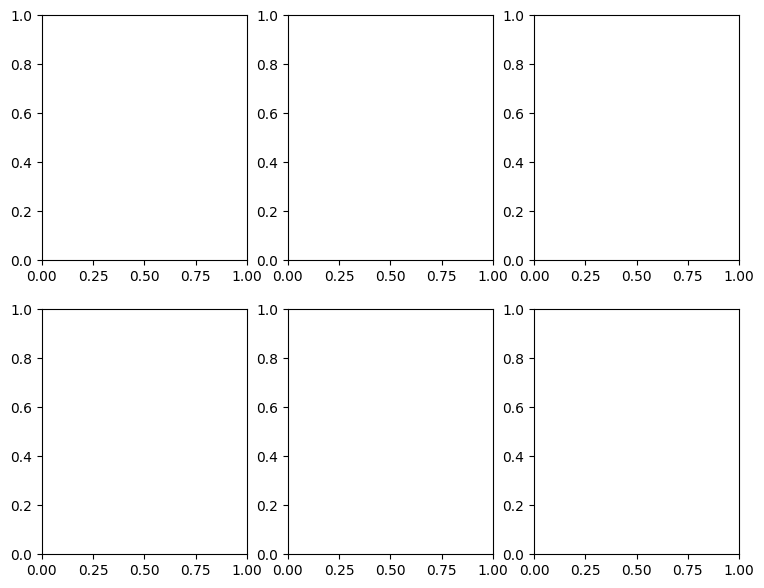

In [16]:
QUERY = 'solitary figure'
TOP_N = 6

print(f'[i] Searching: {QUERY!r}')

proc        = AutoProcessor.from_pretrained(QWEN_EMB_MODEL)
embed_model = AutoModel.from_pretrained(
    QWEN_EMB_MODEL, dtype=torch.float16, attn_implementation='sdpa', device_map='mps'
)
embed_model.eval()

# Text-only message through the same chat template used for images
messages = [{'role': 'user', 'content': [{'type': 'text', 'text': QUERY}]}]
text     = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs   = proc(text=[text], return_tensors='pt', padding=True).to(DEVICE)
with torch.inference_mode():
    out = embed_model(**inputs)
q_emb = out.last_hidden_state[:, -1, :].detach().cpu().float().numpy().flatten()
q_emb /= (np.linalg.norm(q_emb) + 1e-8)

del embed_model, proc
torch.mps.empty_cache()
gc.collect()
print(f'[✓] Query vector ready.')

con  = duckdb.connect(str(DB_PATH))
rows = con.execute('SELECT photo_id, image_path, qwen_emb FROM v6_qwen').fetchall()
con.close()

path_to_umap = {str(p.resolve()): (float(x), float(y))
                for p, (x, y) in zip(valid_paths, vis_2d)}

scored = []
for pid, img_path, qwen_emb in rows:
    sim = float(np.dot(q_emb, np.array(qwen_emb)))
    scored.append((sim, img_path, path_to_umap.get(img_path)))
scored.sort(reverse=True)
top = scored[:TOP_N]

cols = (TOP_N + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 7))
for i, (score, img_path, _) in enumerate(top):
    ax = axes[i // cols][i % cols]
    ax.imshow(safe_to_rgb(Path(img_path)))
    ax.axis('off')
    ax.set_title(f'{score:.3f}  {Path(img_path).name}', fontsize=7)
for ax in axes.flatten()[len(top):]:
    ax.axis('off')
plt.suptitle(f'Search: {QUERY!r}  —  Top {TOP_N}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Highlight matches on UMAP scatter
fig, ax = plt.subplots(figsize=(12, 8))
for cid in sorted(set(int(l) for l in labels)):
    mask = np.array([int(l) == cid for l in labels])
    ax.scatter(vis_2d[mask, 0], vis_2d[mask, 1], c=[_color_hex(cid)], s=18, alpha=0.25, zorder=1)
hit_xy = [pos for _, _, pos in top if pos is not None]
if hit_xy:
    hx, hy = zip(*hit_xy)
    ax.scatter(hx, hy, c='#FFD700', s=200, alpha=0.95,
               edgecolors='#fff', linewidths=1.5, zorder=4, label=f'Top {TOP_N} matches')
ax.legend(fontsize=10)
ax.set_title(f'UMAP — {QUERY!r}', fontsize=13)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

for score, img_path, _ in top:
    idx = next((i for i, p in enumerate(valid_paths) if str(p.resolve()) == img_path), None)
    lbl = labels[idx] if idx is not None else -999
    print(f'  [{score:.3f}] {Path(img_path).name}  —  {"Noise" if lbl == -1 else f"Cluster {lbl}"}')